# SKU Assignment Pipeline — RMFS Replenishment

Follows Rika's baseline: ABC classification from `items_dictionary` drives pod assignment priority.  
No demand-feature clustering — classification is already in the data.

| Phase | Step | Output |
|-------|------|--------|
| 1 | Item-Pod Configuration | `items_slots_configuration.csv`, `best_config_per_sku.csv` |
| 2 | Prepare SKU table (ABC → cluster int) | `sku_sample.csv` |
| 3 | SKU-to-Pod Assignment| `sku_assignment_detail.csv`, `sku_assignment.csv`, `pod_summary.csv` |
| 4 | Convert to Simulation Format | `netlogo/items.csv`, `netlogo/pods.csv` |
| 5 | Run Simulation (Baseline) | `results_baseline/` |
| 6 | Results & Analysis | plots, tables |

## Setup

In [1]:
import sys
import os
from pathlib import Path

# Repo root — adjust if notebook is not in the project root
REPO = Path.cwd()
# REPO = Path("/Users/brendantm/Taiwan/TEEP/rmfs-replenishment")

for _p in [REPO, REPO / "assignment", REPO / "pipeline"]:
    p = str(_p)
    if p not in sys.path:
        sys.path.insert(0, p)

os.chdir(REPO)
print("Working directory:", Path.cwd())

Working directory: /Users/catherinetimony/Documents/Paper APMS/rmfs-replenishment


In [2]:
for f in ["netlogo/generated_database_order.csv", "netlogo/generated_backlog.csv", "netlogo/generated_order.csv"]:
    path = REPO / f
    if path.exists():
        path.unlink()
        print(f"Deleted {path.name}")

Deleted generated_database_order.csv
Deleted generated_backlog.csv
Deleted generated_order.csv


---
## Phase 1 — Item-Pod Configuration

Generates feasible `(item, slot_type, orientation)` rows from box dimensions and slot sizes.

In [3]:
from item_pod_config import load_pod_size, load_items, generate_configs, pick_best_config

slot_df  = load_pod_size(REPO / "pods_dictionary.csv", pod_type=0)
items_df = load_items(REPO / "sku_sample.csv")

print(f"Slot types : {sorted(slot_df['slot_type'].astype(int).tolist())}")
print(f"SKUs       : {len(items_df)}")

[pod_size] Loaded 1 slot type(s):
  slot_type 0: 60 x 50 x 40 (vol=120000.0)  slots_per_pod=10
[items] 1000 items loaded with valid dimensions.
Slot types : [0]
SKUs       : 1000


In [4]:
config_df = generate_configs(items_df, slot_df)

covered   = config_df["item_code"].nunique()
uncovered = len(items_df) - covered
print(f"Total config rows : {len(config_df)}")
print(f"SKUs covered      : {covered}")
print(f"SKUs uncovered    : {uncovered}")

config_df.to_csv(REPO / "items_slots_configuration.csv", index=False)

best_df = pick_best_config(config_df)
best_df.to_csv(REPO / "best_config_per_sku.csv", index=False)

print("Saved items_slots_configuration.csv and best_config_per_sku.csv")

config_df.groupby("slot_type").agg(
    rows=("item_code", "count"),
    skus=("item_code", "nunique"),
    avg_max_boxes=("max_boxes_in_slot", "mean"),
    avg_vol_util=("vol_util_slot", "mean"),
)

Total config rows : 4949
SKUs covered      : 975
SKUs uncovered    : 25
Saved items_slots_configuration.csv and best_config_per_sku.csv


,rows,skus,avg_max_boxes,avg_vol_util
slot_type,,,,
0,4949,975,8.128915,0.482973


---
## Phase 2 — Prepare SKU Table

Reads `sku_sample.csv` (k-means cluster label already present).  
Filters to feasible SKUs (those that fit at least one slot type) and writes the result.

Cluster priority used in assignment (`CLUSTER_PRIORITY = [3, 1, 0, 2]` in `sku_assignment.py`):  
Cluster 3 (high demand) → processed first, Cluster 1 → second, Cluster 0 → third, Cluster 2 → last.

In [5]:
import pandas as pd
import numpy as np

sku_raw = pd.read_csv(REPO / "sku_sample.csv", dtype={"item_code": str})

# Keep all SKUs — infeasible ones (no slot config) are skipped during assignment
sku_sample = sku_raw.copy().reset_index(drop=True)

sku_sample["cluster"] = sku_sample["cluster"].fillna(0).astype(int)

sku_sample.to_csv(REPO / "sku_sample.csv", index=False)

print(f"SKUs in sku_sample.csv: {len(sku_sample)}")
print(sku_sample["cluster"].value_counts().sort_index())

SKUs in sku_sample.csv: 1000
cluster
0    388
1    111
2    472
3     29
Name: count, dtype: int64


---
## Phase 3 — SKU-to-Pod Assignment (FFD)

Greedy FFD algorithm: constrained items first (≤2 compatible slot types), then flexible items, then secondary fill of empty slots.  
Outputs: `sku_assignment_detail.csv`, `sku_assignment.csv`, `pod_summary.csv`, `unassigned_skus.csv`.

In [6]:
from sku_assignment import run_assignment

detail_df = run_assignment(
    base_dir                = REPO,
    sku_sample_path         = REPO / "sku_sample.csv",
    items_dict_path         = REPO / "items_dictionary_cleaned.csv",
    items_slots_config_path = REPO / "items_slots_configuration.csv",
)
print(f"Assignment rows: {len(detail_df)}  |  Pods used: {detail_df['pod_id'].nunique()}")

SKU-to-Pod Assignment  (DC6 / ABC-XYZ Greedy FFD)
  975 best-config rows  (975 unique SKUs)
  1000 SKUs in sample
  Total initial inventory: 10,270 boxes
  [WARN] 25 SKUs have no config entry (no slot fits their dimensions).

Cluster distribution (processed in order: [3, 1, 0, 2]):
  cluster 0:   388 SKUs  (processed 3rd)
  cluster 1:   111 SKUs  (processed 2nd)
  cluster 2:   472 SKUs  (processed 4th)
  cluster 3:    29 SKUs  (processed 1st)

Constrained items (≤2 slot types): 1000
Flexible items    (>2 slot types): 0

[Pass 1+2] Assigning all items (constrained first, then flexible) …
  Pods created       : 215
[Pass 3] Secondary fill of empty slots …
    [secondary_fill] pods=215, total_empty_slots=7
    [secondary_fill] candidate slot types: {0: 975}
  Extra assignments   : 7

  Pods: 215/300, SKUs assigned: 975/975, space util: 62.5%, runtime: 0.5s
  Slots used: 2150 / 3000 total
  Items with unplaced inventory: 25

  cluster   items  pods_used  slots_used  boxes_placed  boxes_tot

### Assignment Results

In [55]:
detail_df = pd.read_csv(REPO / "assignment" / "sku_assignment_detail.csv")
print(f"Rows: {len(detail_df)}  |  Pods used: {detail_df['pod_id'].nunique()}")
detail_df.head(10)

Rows: 2310  |  Pods used: 231


,pod_id,slot_idx,slot_type,item_code,cluster,orientation,qty_boxes_assigned,qty_items_assigned,box_weight,weight_assigned,pod_weight_after,vol_util_slot,max_boxes_in_slot
0,0,0,0,12120083001,0,3,60,60,0.01,0.60,0.60,0.784000,60
1,0,1,0,12201006001,0,0,75,75,0.02,1.50,2.10,1.000000,75
2,0,2,0,10010027001,0,3,18,432,4.34,78.12,80.22,0.792000,18
3,0,3,0,14621021001,0,0,4,48,0.00,0.00,80.22,0.550000,4
4,1,0,0,14621021001,0,0,4,48,0.00,0.00,0.00,0.550000,4
5,2,0,0,14621021001,0,0,4,48,0.00,0.00,0.00,0.550000,4
6,0,4,0,11050094001,0,4,50,50,0.00,0.00,80.22,0.770000,50
7,0,5,0,12202006001,0,3,4,4,1.00,4.00,84.22,0.477400,4
8,1,1,0,12202006001,0,3,4,4,1.00,4.00,4.00,0.477400,4
9,0,6,0,14833059001,0,3,8,96,0.00,0.00,84.22,0.693333,8


In [56]:
sku_df = pd.read_csv(REPO / "assignment" / "sku_assignment.csv")
print(f"SKUs assigned: {len(sku_df)}")
sku_df.head(10)

SKUs assigned: 1000


,item_code,cluster,mean_demand,std_demand,cv_demand,initial_inventory_boxes,qty_inv_items,num_compatible_slots,min_slot_type,total_boxes_assigned,total_items_assigned,total_weight_assigned,pods_used,slots_used,boxes_unplaced
0,14010897001,0,0.142857,0.358569,2.509980,1,0,0,0,0.0,0.0,0.00,0.0,0.0,1
1,32507027002,0,1.428571,3.026077,2.118254,1,0,0,0,0.0,0.0,0.00,0.0,0.0,1
2,14506127001,0,0.142857,0.478091,3.346640,1,0,0,0,0.0,0.0,0.00,0.0,0.0,1
3,32504024001,0,0.571429,2.203893,3.856812,1,0,0,0,0.0,0.0,0.00,0.0,0.0,1
4,14508924001,0,0.095238,0.436436,4.582576,1,0,0,0,0.0,0.0,0.00,0.0,0.0,1
5,12120083001,0,4.952381,12.515895,2.527248,21,0,1,0,60.0,60.0,0.60,1.0,1.0,0
6,12201006001,0,2.285714,10.474459,4.582576,16,0,1,0,1500.0,1500.0,30.00,20.0,20.0,0
7,10010027001,0,43.428571,199.014716,4.582576,13,0,1,0,18.0,432.0,78.12,1.0,1.0,0
8,14621021001,0,16.952381,67.698210,3.993434,9,0,1,0,12.0,144.0,0.00,3.0,3.0,0
9,11050094001,0,1.190476,3.600265,3.024222,6,0,1,0,50.0,50.0,0.00,1.0,1.0,0


Total pods: 231


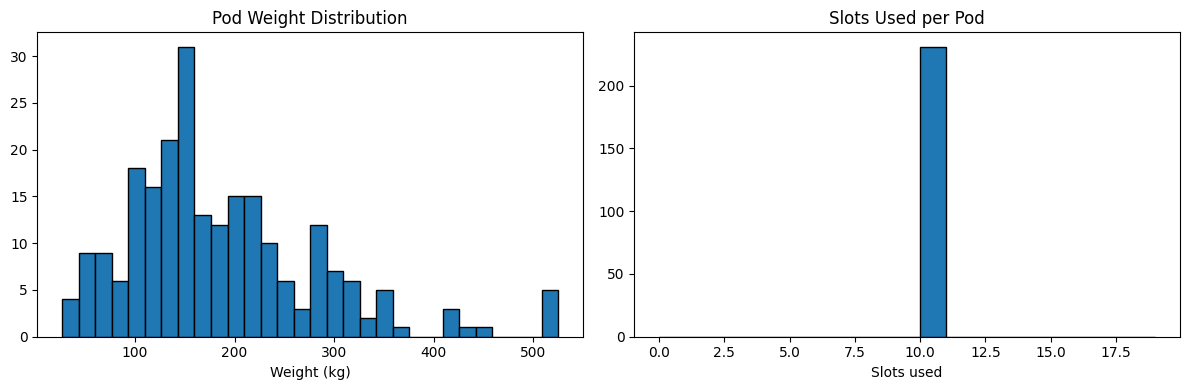

,pod_id,used_slots,total_slots,empty_slots,total_boxes,total_items,total_weight,num_classes
count,231.000000,231.0,231.0,231.0,231.000000,231.000000,231.000000,231.000000
mean,115.000000,10.0,10.0,0.0,95.610390,727.956710,187.332684,1.393939
std,66.828138,0.0,0.0,0.0,99.607118,477.030678,97.740577,0.507130
min,0.000000,10.0,10.0,0.0,18.000000,145.000000,26.886000,1.000000
25%,57.500000,10.0,10.0,0.0,33.000000,348.500000,123.670000,1.000000
50%,115.000000,10.0,10.0,0.0,48.000000,580.000000,163.660000,1.000000
75%,172.500000,10.0,10.0,0.0,129.500000,1023.000000,234.420000,2.000000
max,230.000000,10.0,10.0,0.0,474.000000,2910.000000,524.960000,3.000000


In [57]:
import matplotlib.pyplot as plt

pod_df = pd.read_csv(REPO / "assignment" / "pod_summary.csv")
print(f"Total pods: {len(pod_df)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pod_df["total_weight"], bins=30, edgecolor="black")
axes[0].set_title("Pod Weight Distribution"); axes[0].set_xlabel("Weight (kg)")
axes[1].hist(pod_df["used_slots"], bins=range(0, 20), edgecolor="black")
axes[1].set_title("Slots Used per Pod"); axes[1].set_xlabel("Slots used")
plt.tight_layout(); plt.show()

pod_df.describe()

In [58]:
# Assignment by cluster
if "cluster" in sku_df.columns:
    cs = sku_df.groupby("cluster").agg(
        n_skus=("item_code", "count"),
        boxes_assigned=("total_boxes_assigned", "sum"),
        skus_assigned=("total_boxes_assigned", lambda x: (x > 0).sum()),
    )
    cs["pct_skus_assigned"] = (cs["skus_assigned"] / cs["n_skus"] * 100).round(1)
    print(cs)

         n_skus  boxes_assigned  skus_assigned  pct_skus_assigned
cluster                                                          
0           388         10527.0            383               98.7
1           111          1725.0            103               92.8
2           472          6046.0            461               97.7
3            29          3788.0             28               96.6


In [59]:
import os

unassigned_path = REPO / "assignment" / "unassigned_skus.csv"
if unassigned_path.exists() and os.path.getsize(unassigned_path) > 1:
    unassigned_df = pd.read_csv(unassigned_path)
    print(f"Unassigned SKUs: {len(unassigned_df)}")
    unassigned_df.head(20)
else:
    print("No unassigned_skus.csv — all SKUs fully assigned!")

No unassigned_skus.csv — all SKUs fully assigned!


---
## Phase 4 — Convert to Simulation Format

Translates the FFD assignment into the NetLogo simulator's `items.csv` and `pods.csv` formats.

In [60]:
import sys

# Clear cached modules to ensure latest code is loaded
for mod in list(sys.modules.keys()):
    if 'convert_to_sim' in mod:
        del sys.modules[mod]

import convert_to_sim
from convert_to_sim import generate_items_csv, convert_detail_to_pods_csv

netlogo_dir = REPO / "netlogo"

items_sim = generate_items_csv(
    sku_sample_path = REPO / "sku_sample.csv",
    items_dict_path = REPO / "sku_sample.csv",
    output_path     = netlogo_dir / "items.csv",
)

pods_sim = convert_detail_to_pods_csv(
    detail_df      = detail_df,
    items_df       = items_sim,
    output_path    = netlogo_dir / "pods.csv",
    pods_dict_path = netlogo_dir / "pods_dictionary.csv",
    rop_path       = REPO / "sku_rop.csv",
)

# Merge rop_global from sku_rop.csv into pods.csv
# pods_sim already has item_code column from convert_detail_to_pods_csv
import pandas as pd
rop_df = pd.read_csv(REPO / "sku_rop.csv", dtype={"item_code": str})
rop_df = rop_df[["item_code", "rop_global"]].drop_duplicates()

pods_sim["item_code"] = pods_sim["item_code"].astype(str)
pods_sim = pods_sim.merge(rop_df, on="item_code", how="left")
pods_sim["rop_global"] = pd.to_numeric(pods_sim["rop_global"], errors="coerce").fillna(0).astype(int)
pods_sim.to_csv(netlogo_dir / "pods.csv", index=False)

print(f"items.csv : {len(items_sim)} items")
print(f"pods.csv  : {len(pods_sim)} slot assignments across {pods_sim['pod_id'].nunique()} pods")
print(f"rop_global — min: {pods_sim['rop_global'].min()}, max: {pods_sim['rop_global'].max()}, zeros: {(pods_sim['rop_global'] == 0).sum()} / {len(pods_sim)}")
if 'rop_per_slot' in pods_sim.columns:
    print(f"rop_per_slot — min: {pods_sim['rop_per_slot'].min()}, max: {pods_sim['rop_per_slot'].max()}, zeros: {(pods_sim['rop_per_slot'] == 0).sum()} / {len(pods_sim)}")


  items.csv: 1000 items written to /Users/salsahmd/Downloads/rmfs-replenishment/netlogo/items.csv
  pods.csv: 2310 slots across 231 pods written to /Users/salsahmd/Downloads/rmfs-replenishment/netlogo/pods.csv
items.csv : 1000 items
pods.csv  : 2310 slot assignments across 231 pods
rop_global — min: 0, max: 989, zeros: 478 / 2310
rop_per_slot — min: 0, max: 43, zeros: 478 / 2310


---
## Phase 5 — Run Simulation (Baseline)

Output: `results_baseline/summary.csv`, `tick_metrics.csv`, `orders.csv`.

> Set `MAX_TICKS` lower (e.g. 500) for a quick smoke-test.

In [ ]:
import subprocess

MAX_TICKS = 115200  # smoke test (~41 min simulated time); change to 115200 for full 8-hour run

proc = subprocess.run(
    ["python3", str(REPO / "pipeline" / "run_baseline.py"),
     "--max-ticks", str(MAX_TICKS)],
    text=True,
    capture_output=True,
)
print(proc.stderr)
if proc.stdout:
    print(proc.stdout)
if proc.returncode != 0:
    print(f"[ERROR] process exited with code {proc.returncode}")


  RMFS Baseline Pipeline (Rika's baseline)
  Max ticks: 10000

────────────────────────────────────────────────────────────
  SETUP  Initializing simulation
────────────────────────────────────────────────────────────

  → Running setup()...

  → Setup complete.

────────────────────────────────────────────────────────────
  SIMULATION  Running (max 10000 ticks)
────────────────────────────────────────────────────────────

  Baseline |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 0.5%  2s elapsed | tick 50
  Baseline |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 1.0%  4s elapsed | tick 100
  Baseline |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 1.5%  6s elapsed | tick 150
  Baseline |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 2.0%  7s elapsed | tick 200
  Baseline |█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 2.5%  9s elapsed | tick 250
  Baseline |█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 3.0%  11s elapsed | tick 300
  Baseline |█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 3.5%  13s elapsed | tick 3

In [65]:
import pandas as pd

gen = REPO / "netlogo" / "generated_order.csv"
finished = REPO / "netlogo" / "output" / "order-finished.csv"

if gen.exists():
    df = pd.read_csv(gen)
    df["order_id"] = pd.to_numeric(df["order_id"], errors="coerce")
    print(f"generated_order.csv: {len(df)} rows, {df['order_id'].nunique()} unique orders")
    print(f"  positive IDs (db): {(df['order_id'] >= 0).sum()}")
    print(f"  negative IDs (backlog): {(df['order_id'] < 0).sum()}")
else:
    print("generated_order.csv not found")

if finished.exists():
    df2 = pd.read_csv(finished)
    df2["order_id"] = pd.to_numeric(df2["order_id"], errors="coerce")
    print(f"\norder-finished.csv: {len(df2)} rows")
    print(f"  positive IDs: {(df2['order_id'] >= 0).sum()}")
    print(f"  negative IDs: {(df2['order_id'] < 0).sum()}")
else:
    print("order-finished.csv not found")


generated_order.csv: 1800 rows, 503 unique orders
  positive IDs (db): 1610
  negative IDs (backlog): 190

order-finished.csv: 2 rows
  positive IDs: 0
  negative IDs: 2


---
## Phase 6 — Results & Analysis

In [62]:
results_dir = REPO / "results_baseline"

summary_path = results_dir / "summary.csv"
if summary_path.exists():
    summary = pd.read_csv(summary_path)
    print(summary.T.to_string())
else:
    print("No summary.csv yet — run Phase 5 first.")

                                      0
max_ticks                         10000
pipeline                       baseline
ticks                             10000
orders_finished                       0
total_energy              115193.270938
stop_and_go                         397
total_turning                       243
peak_job_queue                       46
avg_job_queue                      24.4
orders_generated                     39
order_throughput                    0.0
total_picks                          26
total_replenishments                  0
replenishment_pick_ratio            0.0
total_units_picked                  161
pod_visits                           12
pod_utilization                 13.4167


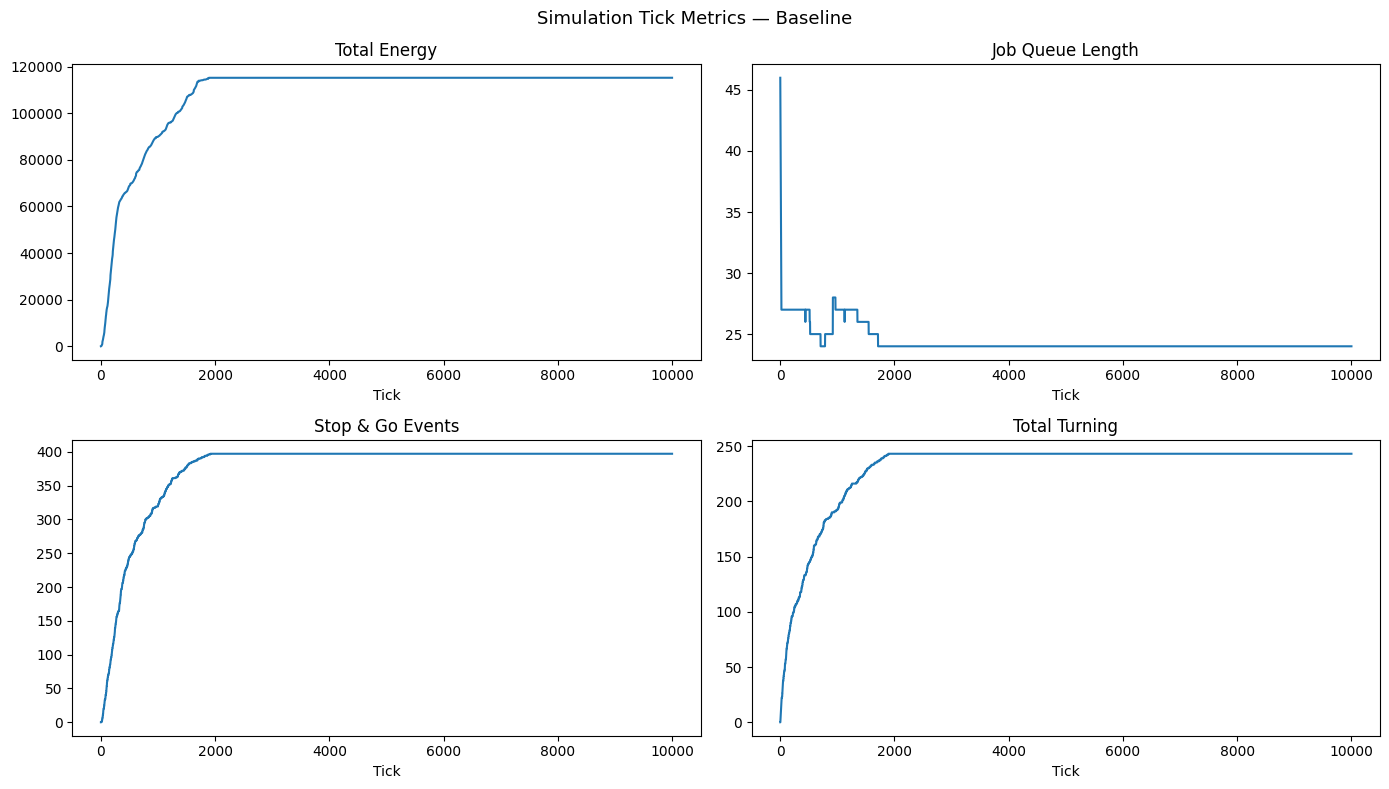

In [63]:
tick_path = results_dir / "tick_metrics.csv"
if tick_path.exists():
    tick_df = pd.read_csv(tick_path)
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for ax, (col, title) in zip(axes.flat, [
        ("total_energy",  "Total Energy"),
        ("job_queue_len", "Job Queue Length"),
        ("stop_and_go",   "Stop & Go Events"),
        ("total_turning", "Total Turning"),
    ]):
        if col in tick_df.columns:
            ax.plot(tick_df["tick"], tick_df[col])
            ax.set_title(title); ax.set_xlabel("Tick")
    plt.suptitle("Simulation Tick Metrics — Baseline", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("No tick_metrics.csv yet — run Phase 5 first.")

count      2.000000
mean     211.000000
std       24.041631
min      194.000000
25%      202.500000
50%      211.000000
75%      219.500000
max      228.000000
Name: cycle_time, dtype: float64


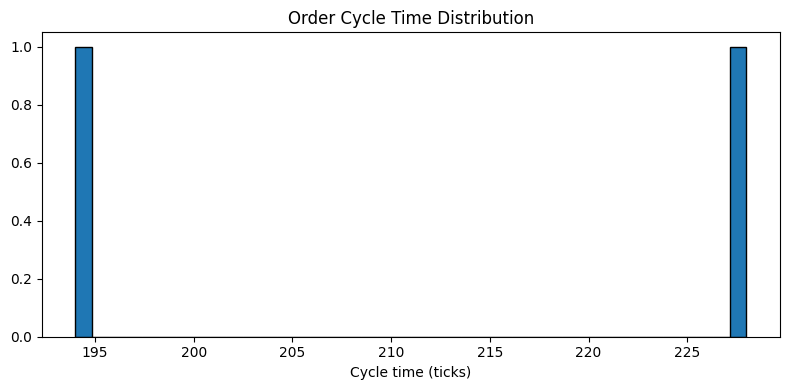

In [64]:
orders_path = results_dir / "orders.csv"
if orders_path.exists():
    orders_df = pd.read_csv(orders_path)
    if "order_complete_time" in orders_df.columns and "process_start_time" in orders_df.columns:
        orders_df["cycle_time"] = orders_df["order_complete_time"] - orders_df["process_start_time"]
        print(orders_df["cycle_time"].describe())
        plt.figure(figsize=(8, 4))
        plt.hist(orders_df["cycle_time"].dropna(), bins=40, edgecolor="black")
        plt.title("Order Cycle Time Distribution"); plt.xlabel("Cycle time (ticks)")
        plt.tight_layout(); plt.show()
    else:
        print(orders_df.head())
else:
    print("No orders.csv yet — run Phase 5 first.")